In [1]:
import json
import numpy as np
import random
import pandas as pd
import math
import time
from copy import deepcopy
import matplotlib.pyplot as plt

In [2]:
dic_day = {'L':'D0', 'Ma':'D1', 'Mi':'D2', 'J':'D3', 'V':'D4'}

In [3]:
def binario(dic, t1, t2):
    param = np.zeros((t1, t2))
    for i, e in enumerate(dic):
        for a in dic[e]:
            j = int(a[1:])
            param[i][j] = 1
    return param
def generar_params(data):
    I = len(data['Employees'])
    J = len(data['Desks'])
    T = len(data['Days'])
    G = len(data['Groups'])
    Z = len(data['Zones'])
    dict_days = data['Days_E'].copy()
    dic_day = {'L':'D0', 'Ma':'D1', 'Mi':'D2', 'J':'D3', 'V':'D4'}
    for a in (dict_days.keys()):
        dict_days[a] = list(map(lambda x:dic_day[x], dict_days[a]))

    DZ = binario(data['Desks_Z'], Z, J)
    EE = binario(data['Desks_E'], I, J)
    EG = binario(data['Employees_G'], G, I)
    DE = binario(dict_days, I, T)
    return DZ, EE, EG, DE

## Penalizaciones

In [4]:
def desk_pref(x, EE):
    count = 0
    for i in x:
        count += np.sum(1-i[EE==1])
    return count

In [5]:
def day_pref(x, DE):
    count = 0
    for j in range(len(x)):
        M = x[:, :, j].T
        count += np.sum(1-M[DE==1])
    return count

In [6]:
def same_desk(x):
    M = np.sum(x, axis=0)
    return len(M[M>0])
    

In [7]:
def isolated_emp(x, EG, DZ):
    Num = np.sum(x, axis=2)@EG.T
    Den = EG @ (x@DZ.T)
    T, G, Z = Den.shape
    CZ = np.zeros((Z, T, G))
    for z in range(Z):
        CZ[z] = np.divide(Num, Den[:, :, z], out=np.zeros_like(Num, dtype=float), where=(Den[:, :, z] != 0))
    
    return np.sum(CZ)    

In [8]:
def isolated_emp(x, EG, DZ):
    zone_emp = EG @ (x@DZ.T)
    return np.sum(zone_emp[zone_emp == 1])  

In [9]:
def FO(x, y, DZ, EE, EG, DE, w=None, weighted=False):
    PE = desk_pref(x, EE)
    PD = day_pref(x, DE)
    ME = same_desk(x)
    EA = isolated_emp(x, EG, DZ)
    if weighted:
        return w[0]*EA+w[1]*PE+w[2]*PD+w[3]*ME
    return EA, PE, PD, ME

## Factibilidad de las Soluciones

In [10]:
def delete_day(emp, x, employs_days, random_=True, days_subset=None):
    x_new = x.copy()
    e_day = employs_days[:, emp]
    e_day = np.where(e_day==1)[0][0]
    days_assign = np.where((x_new[:, emp, :].sum(axis=1) > 0))[0]
    if days_subset is not None:
        days_assign = days_assign[np.isin(days_assign, days_subset)]
        days_assign = days_assign[days_assign != e_day]
    else:
        days_assign = days_assign[days_assign != e_day]
    if random_:
        day = np.random.default_rng().choice(days_assign)
    else:
        day = days_assign[0]
    if day==e_day:
        print('Falla')
    x_new[day, emp, :] = 0
    return x_new
def count_emp_days(x):
    return x.sum(axis=(0, 2))

def fix_days_emp(x, employs_days, random_=True):
    T, I, J = x.shape
    x_perm = x.copy()
    #Contador de días que va cada empleado
    days_emp = count_emp_days(x)
    great_emp = np.where(days_emp>3)[0]
    low_emp =  np.where(days_emp<2)[0]
    #Si el empleado va más de 3 días se elimina uno de ellos (omitiendo el día de su grupo)
    for i in great_emp:
        x_perm = delete_day(i, x_perm, employs_days, random_)
    #Si el empleado va menos de 2 días se le añade un día
    for i in low_emp:
        #Días a los que el empleado aún no está asignado
        av_days = np.where((x_perm[:, i, :].sum(axis=1) == 0))[0]
        #Días disponibles para el empleado que tienen escritorios
        av_days_desk = av_days[np.sum(x_perm[av_days, :, :], axis=(1, 2)) < J]
        #Si no hay días con escritorio se debe eliminar un empleado con 3 días
        if len(av_days_desk) == 0:
            delete_employees = np.where(np.sum(x_perm[av_days, :, :], axis=(0, 2)) >=3)[0]
            if random_:
                delete_emp = np.random.default_rng().choice(delete_employees)
            else:
                delete_emp = delete_employees[0]
            x_perm = delete_day(delete_emp, x_perm, employs_days, random_)
            av_days = np.where((x_perm[:, i, :].sum(axis=1) == 0))[0]
            av_days_desk = av_days[np.sum(x_perm[av_days, :, :], axis=(1, 2)) < J]
        if random_:
            day = np.random.default_rng().choice(av_days_desk)
        else:
            day = av_days_desk[0]
        
        av_desk = np.where(x_perm[day, :, :].sum(axis=0) == 0)[0]

        if random_:
            desk = np.random.default_rng().choice(av_desk)
        else:
            desk = av_desk[0]
        x_perm[day, i, desk] = 1
    
        
    return x_perm

In [11]:
def group_day(x, y, EG, random_=True):
    T, I, J = x.shape
    G = y.shape[1]
    x_perm = x.copy()
    if not R3(x, y, EG):
        for g in range(G):
            day = np.where(y[:, g] == 1)[0][0]
            
            #Distribución de los escritorio ese día
            desk_dist = np.sum(x_perm[day], axis=0)
            #Escritorios disponibles
            av_desk = np.sum(desk_dist==0)

            #Empleados de los grupos que deben ir completos ese día
            emp_group = np.where(EG[g, :] == 1)[0]
            #Cantidad de empleados que pertenecen al grupo que debe ir ese día pero no están asignados
            not_day_emp = sum(np.sum(x_perm[day][emp_group], axis=1) == 0)

            #Variable para identificar si faltan escritorios para asignar a los empleados que deben ir ese día
            miss_desk = not_day_emp - av_desk 
            #Si es positivo entonces faltan escritorios y se deben eliminar empleados que no deben ir obligatoriamente ese día
            if miss_desk > 0:
                #Empleados que no deben ir obligatoriamente ese día (porque no pertenecen al grupo del día)
                not_group_emp = np.where(y[day]@EG == 0)[0]
                #Empleados que no deben ir obligatoriamente ese día y van
                not_group_emp_day = not_group_emp[np.sum(x_perm[day, not_group_emp, :], axis=1) == 1]
                #Escoger aleatoriamente empleados a eliminar hasta tener suficientes escritorios
                if random_:
                    chosen = np.random.choice(not_group_emp_day, size=miss_desk, replace=False)
                else:
                    chosen = not_group_emp_day[:miss_desk]

                x_perm[day, chosen, :] = 0 
                
                
            #Lista de empleados del grupo que aún no tienen escritorio
            employ_list = emp_group[np.sum(x_perm[day][emp_group], axis=1) == 0]
            desk_dist = np.sum(x_perm[day], axis=0)
            desk_list = np.where(desk_dist == 0)[0]
            x_day = x_perm[day]
            for desk, employ in enumerate(employ_list):
                x_day[employ][desk_list[desk]] = 1
        employs_days = y@EG
        x_perm = fix_days_emp(x_perm, employs_days, random_)
            
    return x_perm

## Restricciones

In [12]:
#Un escritorio solo puede ser asignado a lo sumo a un empleado en un mismo día
def R1(x, smooth_const=False):
    x_R1 = np.sum(x, axis=1)
    if smooth_const:
        return sum(x_R1[x_R1>1])
    
    penalty1 = len(x_R1[x_R1>1])
    if penalty1>0:
        return False
    return True

#Solo es posible asignarle un escritorio a un empleado en un mismo día
def R2(x, smooth_const=False):
    x_R2 = np.sum(x, axis=2)
    if smooth_const:
        return sum(x_R2[x_R2>1])
        
    penalty2 = len(x_R2[x_R2>1])
    if penalty2>0:
        return False
    return True

#Todos los empleados de un grupo deben ir el día asignado a su grupo
def R3(x, y, EG, smooth_const=False):
    right_R3 = np.sum(EG, axis=1) * y
    left_R3 = (np.sum(x, axis=2)@EG.T) * y
    var_R3 = np.abs(left_R3 - right_R3)
    if smooth_const:
        return sum(var_R3[var_R3>0])
        
    penalty3 = len(var_R3[np.abs(var_R3)>0])
    if penalty3>0:
        return False
    return True

#Los grupos solo pueden reunirse un día a la semana
def R4(y, smooth_const=False):
    y_R4 = np.abs(np.sum(y, axis=0)-1)
    if smooth_const:
        return sum(y_R4[y_R4>0])    

    penalty4 = len(y_R4[y_R4>0])
    if penalty4>0:
        return False
    return True


#Los empleados solo pueden ir un número específico de días
def R5(x, smooth_const=False):
    x_R5 = count_emp_days(x)
    if smooth_const:
        return sum(x_R5[(x_R5<2) | (x_R5>3)])    
    
    penalty5 = len(x_R5[(x_R5<2) | (x_R5>3)])
    if penalty5>0:
        return False
    return True

#La cantidad de escritorios debe ser suficiente para albergar a los grupos asignados a ese día
def R6(desks, y, EG, smooth_const=False):
    var_R6 = np.sum(y@EG, axis=1)
    if smooth_const:
        return sum(var_R6[var_R6>desks])
    penalty6 = len(var_R6[var_R6>desks])
    if penalty6>0:
        return False
    return True

In [13]:
def const(x, y, DZ, EE, EG, DE, smooth_const_list=[False for i in range(6)]):
    desks = x.shape[2]
    return [R1(x, smooth_const_list[0]), R2(x, smooth_const_list[1]), R3(x, y, EG, smooth_const_list[2]), 
            R4(y, smooth_const_list[3]), R5(x, smooth_const_list[4]), R6(desks, y, EG, smooth_const_list[5])]

# Método Constructivo

In [14]:

# -----------------------
# Helpers (deterministic)
# -----------------------
def binario(dic, t1, t2):
    param = np.zeros((t1, t2), dtype=int)
    for i, e in enumerate(dic):
        for a in dic[e]:
            j = int(a[1:])
            param[i, j] = 1
    return param

def build_y_from_assignments(assignments, T, G):
    y = np.zeros((T, G), dtype=int)
    for g, d in enumerate(assignments):
        if d >= 0:
            y[d, g] = 1
    return y

def build_x_from_map(assign_map, T, I, J):
    x = np.zeros((T, I, J), dtype=int)
    for (t, i), j in assign_map.items():
        x[t, i, j] = 1
    return x

def desks_in_zone(DZ, z):
    # DZ: Z x J
    return [j for j in range(DZ.shape[1]) if DZ[z, j] == 1]

def desk_zone(DZ, j):
    # return first zone index for desk j (deterministic)
    zs = [z for z in range(DZ.shape[0]) if DZ[z, j] == 1]
    return zs[0] if zs else None

# -----------------------
# Core algorithm
# -----------------------
def constructive_simple(EG, DE, EE, DZ, min_days=2, max_days=3):
    """
    EG: G x I
    DE: I x T
    EE: I x J
    DZ: Z x J
    returns: x (T x I x J), y (T x G), assignments (group->day), current_assign_map, diagnostics
    """
    G, I = EG.shape
    T = DE.shape[1]
    J = EE.shape[1]
    Z = DZ.shape[0]

    # 1) compute group preferences (how many members available per day)
    GD = EG @ DE  # G x T, higher means more members available/prefer that day
    ranked_days = np.argsort(-GD, axis=1)  # G x T, descending order

    # 2) Assign groups to days using the rule:
    chosen_days = set()
    assignments = -1 * np.ones(G, dtype=int)
    for g in range(G):
        # try preferred days in order; pick first not already chosen
        placed = False
        for d in ranked_days[g]:
            if d not in chosen_days:
                assignments[g] = int(d)
                chosen_days.add(int(d))
                placed = True
                break
        if not placed:
            # all days claimed; assign best day anyway (guarantee one day per group)
            assignments[g] = int(ranked_days[g, 0])
            # do NOT add to chosen_days because duplicates allowed now

    y = build_y_from_assignments(assignments, T, G)

    # 3) Assign employees for their group's main day + desks (deterministic)
    free_desks_by_day = np.ones((T, J), dtype=int)  # 1 = free
    current_assign_map = {}  # (t,i) -> j

    # Helper: pair-place members of a group on a given day when possible
    def pair_place_members(members, day):
        """
        Try deterministic pairing per zone for the given members on day.
        Returns dict of assignments (day, i)->j for those members, or partial dict if some can be placed.
        """
        assigned = {}
        unassigned = list(members)

        # build candidate desks per member (available & preferred)
        member_cands = {}
        free_desks = {j for j in range(J) if free_desks_by_day[day, j] == 1}
        # exclude desks already used on that day in current_assign_map
        for (tt, ii), jj in current_assign_map.items():
            if tt == day and jj in free_desks:
                free_desks.remove(jj)

        for i in members:
            c = [j for j in range(J) if EE[i, j] == 1 and j in free_desks]
            c.sort()
            member_cands[i] = c

        # First: try to place in pairs inside each zone
        for z in range(Z):
            desks_z = [j for j in range(J) if DZ[z, j] == 1 and j in free_desks]
            desks_z.sort()
            if len(desks_z) < 2:
                continue
            # members who can use zone z
            can_here = [i for i in unassigned if any(j in desks_z for j in member_cands[i])]
            can_here.sort()
            while len(can_here) >= 2 and len(desks_z) >= 2:
                i1 = can_here.pop(0)
                i2 = can_here.pop(0)
                # pick first compatible desks
                j1 = next((j for j in member_cands[i1] if j in desks_z), None)
                if j1 is None:
                    continue
                desks_z.remove(j1)
                j2 = next((j for j in member_cands[i2] if j in desks_z), None)
                if j2 is None:
                    # rollback j1 to desks_z and continue
                    desks_z.append(j1); desks_z.sort()
                    continue
                desks_z.remove(j2)
                assigned[(day, i1)] = j1
                assigned[(day, i2)] = j2
                free_desks.remove(j1); free_desks.remove(j2)
                unassigned.remove(i1); unassigned.remove(i2)
                # update member_cands (remove used desks)
                for ii in members:
                    member_cands[ii] = [jj for jj in member_cands[ii] if jj not in (j1, j2)]
                can_here = [i for i in unassigned if any(j in desks_z for j in member_cands[i])]
                can_here.sort()

        # Second: try to place remaining members individually on preferred desks (avoid creating singleton if possible)
        for i in sorted(unassigned):
            # try preferred desks first (that are still free)
            cands = [j for j in member_cands[i] if j in free_desks]
            placed = False
            for j in cands:
                # check zone singleton risk: if this desk's zone would have exactly 1 member from this group after placing -> try next desk
                z = desk_zone(DZ, j)
                # count current group members in that zone on the day (including those already assigned in 'assigned')
                group_zone_count = 0
                for (tt, ii), jj in list(current_assign_map.items()) + list(assigned.items()):
                    if tt == day and EG[:, ii].size:  # placeholder check
                        # We need to check if ii belongs to same group as these members - simpler: we will avoid creating singleton by preferring desks where another group mate is present
                        pass
                # for simplicity here: place them if desk is free
                assigned[(day, i)] = j
                free_desks.remove(j)
                unassigned.remove(i)
                placed = True
                break
            # if not placed on preferred desks, try any free desk (deterministic)
            if not placed and free_desks:
                j = min(free_desks)
                assigned[(day, i)] = j
                free_desks.remove(j)
                unassigned.remove(i)

        return assigned, unassigned  # assigned dict may be partial

    # For each group in deterministic order, place members on group's assigned day
    for g in range(G):
        d = int(assignments[g])
        members = list(np.where(EG[g] == 1)[0])
        # try to pair-place members on day d
        placed_map, leftover = pair_place_members(members, d)
        # commit placed_map
        for (tt, i), j in placed_map.items():
            current_assign_map[(tt, i)] = j
            free_desks_by_day[tt, j] = 0
        # if leftover remain, try to place them on that same day using any free preferred desk
        for i in sorted(leftover):
            # try preferred desks
            pref = [j for j in range(J) if EE[i, j] == 1 and free_desks_by_day[d, j] == 1]
            if pref:
                j = pref[0]
                current_assign_map[(d, i)] = j
                free_desks_by_day[d, j] = 0
            else:
                # try any free desk
                free_list = [jj for jj in range(J) if free_desks_by_day[d, jj] == 1]
                if free_list:
                    j = free_list[0]
                    current_assign_map[(d, i)] = j
                    free_desks_by_day[d, j] = 0
                else:
                    # no desk left on group's day; leave for repair/second-day step
                    pass

    # 4) Assign second day for each employee in order (deterministic) respecting availability DE and desk prefs
    # Build a quick function to check current days count for employee
    def assigned_days_of(i):
        return sorted({t for (t, ii) in current_assign_map.keys() if ii == i})

    for i in range(I):
        days_i = assigned_days_of(i)
        # if already has >=2 days, skip (but ensure not exceed max_days)
        if len(days_i) >= min_days:
            continue
        # find candidate second days by DE preference descending excluding already assigned days
        cand_days = [d for d in np.argsort(-DE[i]) if d not in days_i]
        for d in cand_days:
            # try to place on day d using a preferred desk
            pref_desks = [j for j in range(J) if EE[i, j] == 1 and free_desks_by_day[d, j] == 1]
            if pref_desks:
                j = pref_desks[0]
                current_assign_map[(d, i)] = j
                free_desks_by_day[d, j] = 0
                break
            # else try any free desk
            free_list = [jj for jj in range(J) if free_desks_by_day[d, jj] == 1]
            if free_list:
                j = free_list[0]
                current_assign_map[(d, i)] = j
                free_desks_by_day[d, j] = 0
                break
        # after loop, employee may have been assigned their second day or not

        # ensure not exceeding max_days (we only add one second day here so max won't be violated)

    # 5) Build final x,y
    x = build_x_from_map(current_assign_map, T, I, J)
    y = build_y_from_assignments(assignments, T, G)

    # Diagnostics / tables
    # group-day table
    days_names = ["L", "Ma", "Mi", "J", "V"][:T]
    df_group_day = pd.DataFrame({
        "Group": [f"G{g}" for g in range(G)],
        "Day": [days_names[d] if d >= 0 else "Unassigned" for d in assignments]
    })

    # Employee-day matrix
    matrix = [["-" for _ in range(T)] for _ in range(I)]
    for (t, ii), jj in current_assign_map.items():
        matrix[ii][t] = f"D{jj}"
    df_emp_matrix = pd.DataFrame(matrix, index=[f"E{i}" for i in range(I)], columns=days_names)

    # Day summary
    day_counts = {days_names[d]: 0 for d in range(T)}
    for (t, ii), jj in current_assign_map.items():
        day_counts[days_names[t]] += 1
    df_day_summary = pd.DataFrame(list(day_counts.items()), columns=["Day", "Total Employees"])

    diagnostics = {
        "current_assign_map": current_assign_map,
        "free_desks_by_day": free_desks_by_day
    }

    return x, y, assignments, df_group_day, df_emp_matrix, df_day_summary, diagnostics


# Método Constructivo Aleatorizado

In [15]:
def constructive_randomized_controlled(EG, DE, EE, DZ, min_days=2, max_days=3, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    G, I = EG.shape
    T = DE.shape[1]
    J = EE.shape[1]

    # 1) Preferencias de los grupos
    GD = EG @ DE  # G x T
    ranked_days = np.argsort(-GD, axis=1)

    # 2) Aleatorizar el orden de asignación de grupos
    group_order = list(range(G))
    random.shuffle(group_order)

    # 3) Asignar días principales a cada grupo
    chosen_days = set()
    assignments = -1 * np.ones(G, dtype=int)
    for g in group_order:
        placed = False
        for d in ranked_days[g]:
            if d not in chosen_days:
                assignments[g] = int(d)
                chosen_days.add(int(d))
                placed = True
                break
        if not placed:
            assignments[g] = int(ranked_days[g, 0])

    # 4) Asignar empleados a escritorios en su día principal
    free_desks_by_day = np.ones((T, J), dtype=int)
    current_assign_map = {}

    for g in group_order:
        d = int(assignments[g])
        members = list(np.where(EG[g] == 1)[0])
        for i in members:
            pref = [j for j in range(J) if EE[i, j] == 1 and free_desks_by_day[d, j] == 1]
            if pref:
                j = pref[0]
                current_assign_map[(d, i)] = j
                free_desks_by_day[d, j] = 0
            else:
                free_list = [jj for jj in range(J) if free_desks_by_day[d, jj] == 1]
                if free_list:
                    j = free_list[0]
                    current_assign_map[(d, i)] = j
                    free_desks_by_day[d, j] = 0

    # 5) Aleatorizar orden de empleados para el segundo día
    employee_order = list(range(I))
    random.shuffle(employee_order)

    def assigned_days_of(i):
        return sorted({t for (t, ii) in current_assign_map.keys() if ii == i})

    for i in employee_order:
        days_i = assigned_days_of(i)
        if len(days_i) >= min_days:
            continue
        cand_days = [d for d in np.argsort(-DE[i]) if d not in days_i]
        for d in cand_days:
            pref_desks = [j for j in range(J) if EE[i, j] == 1 and free_desks_by_day[d, j] == 1]
            if pref_desks:
                j = pref_desks[0]
                current_assign_map[(d, i)] = j
                free_desks_by_day[d, j] = 0
                break
            free_list = [jj for jj in range(J) if free_desks_by_day[d, jj] == 1]
            if free_list:
                j = free_list[0]
                current_assign_map[(d, i)] = j
                free_desks_by_day[d, j] = 0
                break

    # 6) Salidas estándar
    x = np.zeros((T, I, J), dtype=int)
    for (t, i), j in current_assign_map.items():
        x[t, i, j] = 1

    y = np.zeros((T, G), dtype=int)
    for g, d in enumerate(assignments):
        if d >= 0:
            y[d, g] = 1

    days_names = ["L", "Ma", "Mi", "J", "V"][:T]
    df_group_day = pd.DataFrame({
        "Group": [f"G{g}" for g in range(G)],
        "Day": [days_names[d] if d >= 0 else "Unassigned" for d in assignments]
    })

    matrix = [["-" for _ in range(T)] for _ in range(I)]
    for (t, ii), jj in current_assign_map.items():
        matrix[ii][t] = f"D{jj}"
    df_emp_matrix = pd.DataFrame(matrix, index=[f"E{i}" for i in range(I)], columns=days_names)

    day_counts = {days_names[d]: 0 for d in range(T)}
    for (t, ii), jj in current_assign_map.items():
        day_counts[days_names[t]] += 1
    df_day_summary = pd.DataFrame(list(day_counts.items()), columns=["Day", "Total Employees"])

    return x, y, df_group_day, df_emp_matrix, df_day_summary, assignments, current_assign_map

# Método Aleatorizado: Recocido Simulado

In [16]:
def swap(var, ax=None, i1=None, i2=None):
    new_var = var.copy()
    coord = new_var.shape
    if ax==None:
        ax = random.randint(0, 1)
    if ax==0:
        if i1==None:
            i1, i2 = random.sample(range(coord[0]), 2)
        a, b = new_var[i1, :].copy(), new_var[i2, :].copy()
        new_var[i1, :], new_var[i2, :] = b, a
    else:
        if i1==None:
            i1, i2 = random.sample(range(coord[1]), 2)
        a, b = new_var[:, i1].copy(), new_var[:, i2].copy()
        new_var[:, i1], new_var[:, i2] = b, a
            
        
    return new_var

In [17]:
def insert(var, ax, i1=None, i2=None):
    new_var = var.copy()
    rows, cols = new_var.shape
    
    if i1==None:
        if ax == 0:
            i1, i2 = random.sample(range(rows), 2)
        else:
            i1, i2 = random.sample(range(cols), 2)
            
    if ax == 0:
        row = new_var[i1, :].copy()
        new_var = np.delete(new_var, i1, axis=0)   
        new_var = np.insert(new_var, i2, row, axis=0) 
    else:
        col = new_var[:, i1].copy()
        new_var = np.delete(new_var, i1, axis=1)   
        new_var = np.insert(new_var, i2, col, axis=1) 
    
    return new_var


In [18]:
import math
import copy
def simulated_annealing(x, y, params, t, a, niter, max_rep, max_iter, weighted=False, thresholds=None):
    sol = [x, y]
    fo_0 = FO(*sol, *params, weighted)
    prev_fo = fo_0
    DZ, EE, EG, DE, w = params
    reps = 0
    c_iter = 0
    iters = 0
    while reps < max_rep and iters < max_iter:
        stop = False
        while not stop:
            r = random.randint(0, 1)
            if r==0:
                y_sol = swap(y)
            else:
                y_sol = insert(y, ax=1)
            x_adj = x.copy()
            try:
                x_sol = group_day(x_adj, y_sol, EG)
                stop = True
            except:
                continue
        for i in range(niter):
            iters+=1
            #print()
            if reps == max_rep:
                break
            #print(f'Función objetivo: {fo_0}, Temperatura: {t}, reps: {reps}')
            c_iter +=1        
            #for j in range(x_swap.shape[0]):
            j = np.random.randint(0, 4)
            r2 = random.randint(0, 1)
            if r2==0:
                x_sol[j] = swap(x_sol[j])
            else:
                x_sol[j] = insert(x_sol[j], ax=0)
            new_sol = [x_sol, y_sol]
            if False not in const(*new_sol, *params[:-1]):
                fo_new = FO(*new_sol, *params, weighted)
                delta1 = fo_new[0] - fo_0[0]
                delta2 = fo_new[1] - fo_0[1]
                delta3 = fo_new[2] - fo_0[2]
                delta4 = fo_new[3] - fo_0[3]
                
                if delta1 < 0 or random.random() < math.exp(min(700, -delta1/t)):
                    prev_fo = fo_0
                    sol[0] = new_sol[0].copy()
                    sol[1] = new_sol[1].copy()
                    fo_0 = fo_new
                elif (delta1 <= thresholds[0][0]) and (delta2 < 0 or random.random() < math.exp(min(700, -delta2/t))):
                    prev_fo = fo_0
                    sol[0] = new_sol[0].copy()
                    sol[1] = new_sol[1].copy()
                    fo_0 = fo_new
                elif (delta1 <= thresholds[1][0]) and delta2 <= thresholds[1][1] and (delta3 < 0 or random.random() < math.exp(min(700, -delta3/t))):
                    prev_fo = fo_0
                    sol[0] = new_sol[0].copy()
                    sol[1] = new_sol[1].copy()
                    fo_0 = fo_new
                elif (delta1 <= thresholds[2][0]) and delta2 <= thresholds[2][1] and delta3 <= thresholds[2][2] and (delta4 < 0 or random.random() < math.exp(min(700, -delta4/t))):
                    prev_fo = fo_0
                    sol[0] = new_sol[0].copy()
                    sol[1] = new_sol[1].copy()
                    fo_0 = fo_new
                else:
                    prev_fo = fo_0
            else:
                prev_fo = fo_0
            if prev_fo == fo_0:
                reps += 1
            else:
                reps = 0
        t = a*t
    #fo_0 = 
    return copy.deepcopy(sol), tuple(fo_0), c_iter


In [19]:
w = [1, 0, 0, 0]

## Solución Inicial Aleatoria

In [20]:
import math
def initial_sol(T, I, J, G):
    x = np.zeros((T, I, J))
    rows = np.random.randint(0, T, size=G)
    y = np.zeros((T, G))
    y[rows, np.arange(G)] = 1
    slices = I//J
    
    for i in range(T):
        if i < slices:
            np.fill_diagonal(x[i][i*J:(i+1)*J, :], 1)
        elif i%2==0:
            np.fill_diagonal(x[i][:J, :], 1)
        else:
            np.fill_diagonal(x[i][I-J:, :], 1)
    return x, y


# Evaluación para Cada instancia

In [21]:
with open(f"instances/instance10.json", "r", encoding="utf-8") as f:
        data = json.load(f)


In [22]:
import time

def evaluate(instance, t, a, niter, thresholds, runs, method=0):
    with open(f"instances/instance{instance}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    I = len(data['Employees'])
    J = len(data['Desks'])
    T = len(data['Days'])
    G = len(data['Groups'])
    Z = len(data['Zones'])
    DZ, EE, EG, DE = generar_params(data)
    if method<=1:
        if method==0:
            x, y = initial_sol(T, I, J, G)
            while True:
                x, y = initial_sol(T, I, J, G)
                if R6(J, y, EG):
                    try:
                        x = group_day(x, y, EG)
                        break
                    except:
                        continue
        
            x_c, y_c, assignments, df_group_day, df_emp_matrix, df_day_summary, diag = constructive_simple(EG, DE, EE, DZ)
            
            f_initial_r = FO(x, y, DZ, EE, EG, DE, [0.5, 0.3, 0.2, 0.1], True)
            f_const = FO(x_c, y_c, DZ, EE, EG, DE, [0.5, 0.3, 0.2, 0.1], True)
            if f_const < f_initial_r:
                x, y = x_c, y_c
        else:
            start = time.time()
            x, y, df_group_day, df_emp_matrix, df_day_summary, assignments, current_assign_map = constructive_randomized_controlled(EG, DE, EE, DZ)
            end = time.time()
        
        f_initial = FO(x, y, DZ, EE, EG, DE, None) 
        
        
        if method == 0:
            start = time.time()
            [x_best, y_best], f_best, c = simulated_annealing(x, y, [DZ, EE, EG, DE, None], t, a, niter, 50, 10000, thresholds=thresholds)
            end = time.time()
        else:
            x_best, y_best, f_best = x, y, f_initial
        
        timer = end - start
        for _ in range(runs-1):
            start = time.time()
            if method == 0:
                [x_sol, y_sol], f_sol, c = simulated_annealing(x, y, [DZ, EE, EG, DE, None], t, a, niter, 50, 10000, thresholds=thresholds)
            else:
                x_sol, y_sol, df_group_day, df_emp_matrix, df_day_summary, assignments, current_assign_map = constructive_randomized_controlled(EG, DE, EE, DZ)
                f_sol = FO(x_sol, y_sol, DZ, EE, EG, DE, None) 
            end = time.time()
            timer += end - start
            if f_sol[0] < f_best[0]:
                x_best, y_best, f_best = x_sol.copy(), y_sol.copy(), f_sol
            elif (f_sol[0] - f_best[0] <= 1) and (f_sol[1] < f_best[1]):
                x_best, y_best, f_best = x_sol.copy(), y_sol.copy(), f_sol
            elif (f_sol[0] == f_best[0]) and (f_sol[1] - f_best[1] <= 5) and (f_sol[2] < f_best[2]):
                x_best, y_best, f_best = x_sol.copy(), y_sol.copy(), f_sol
            elif (f_sol[0] == f_best[0]) and (f_sol[1] == f_best[1]) and (f_sol[2] == f_best[2]) and (f_sol[3] < f_best[3]):
                x_best, y_best, f_best = x_sol.copy(), y_sol.copy(), f_sol    
             
    else:
        start = time.time()
        x_best, y_best, assignments, df_group_day, df_emp_matrix, df_day_summary, diag = constructive_simple(EG, DE, EE, DZ)
        f_initial = None
        f_best =  FO(x_best, y_best, DZ, EE, EG, DE, None)
        end = time.time()
        timer = end - start
        runs = 1
        
    timer/=runs
    valid_assignments = 5*np.sum(EE) - f_best[1]
    employee_preferences = 5*np.sum(DE) - f_best[2]
    isolated_employees = f_best[0]
    return x_best, y_best, f_best, f_initial, timer, valid_assignments, employee_preferences, isolated_employees
    
    

In [23]:
def format_p(x, y):
    table_emp_day = []
    T, I, J = x.shape
    G = y.shape[1]
    for m in x:
        employees = np.full(I, None, dtype=f'<U{J}') 
        rows, cols = np.where(m == 1)                        
        for r, c in zip(rows, cols):
            employees[r] = f'D{c+1}'                         
        table_emp_day.append(employees)

    group_day = np.full(G, '', dtype=f'<U{T}')
    dic_day_inv = {0:'L', 1:'Ma', 2:'Mi', 3:'J', 4:'V'}
    rows, cols = np.where(y == 1)                        
    for r, c in zip(rows, cols):
        group_day[c] = dic_day_inv[r]
    return table_emp_day, group_day
    
        

In [24]:
import pandas as pd

def export_assignments_to_excel(result, filename):
    table_emp_day, group_day = format_p(result[0], result[1])
    arr = np.asarray(table_emp_day)
    if arr.ndim != 2:
        raise ValueError("table_emp_day debe ser una lista/array de forma (T, I)")

    T, I = arr.shape
    G = len(group_day)

    default = ['L', 'Ma', 'Mi', 'J', 'V']
    day_labels = default[:T]


    employee_names = [f"E{i}" for i in range(I)]
    group_names = [f"G{g}" for g in range(G)]

    df_employees = pd.DataFrame(arr.T, index=employee_names, columns=day_labels)

    df_groups = pd.DataFrame({ 'Meeting Day': list(group_day) }, index=group_names)

    df_summary = pd.DataFrame([[result[-3]], [result[-2]], [result[-1]]], index=['Valid assignments', 'Employee preferences', 'Isolated employees'])
    
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        df_employees.to_excel(writer, sheet_name='EmployeeAssingment')
        df_groups.to_excel(writer, sheet_name='Groups Meeting day')
        df_summary.to_excel(writer, sheet_name='Summary')
        


## Soluciones Método Aleatorizado

In [25]:
temp= [10, 10, 25, 25, 25, 25, 30, 30, 40, 40]
ratios = [0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9]
niters = [30, 30, 20, 20, 20, 20, 20, 20, 20, 20]
thresholds = [[3], [1, 10], [1, 5, 5]]

In [26]:
results_random = []
for i in range(10):
    results_random.append(evaluate(i+1, temp[i], ratios[i], niters[i], thresholds, 10))

In [27]:
results_random

[(array([[[0, 0, 0, 0, 0, 0, 1, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 1, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 1, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 1],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 1, 0, 0, 0, 0, 0, 0, 0],
          [1, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 1, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 1, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 1, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0]],
  
         [[0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 0, 0, 0, 0],
          [1, 0, 0, 0

In [28]:
for i in range(10):
    filename = f'Aleatorizado/Aleatorio_Resultados_Instancia {i+1}.xlsx'
    export_assignments_to_excel(results_random[i], filename)

## Soluciones Método Constructivo

In [29]:
results_const = []
for i in range(10):
    results_const.append(evaluate(i+1, None, None, None, None, 1, method=2))

for i in range(10):
    filename = f'Constructivo/Constructivo_Resultados_Instancia {i+1}.xlsx'
    export_assignments_to_excel(results_const[i], filename)


## Soluciones Método Constructivo Aleatorizado

In [30]:
results_const_random = []
for i in range(10):
    results_const_random.append(evaluate(i+1, None, None, None, None, 1, method=1))

for i in range(10):
    filename = f'Constructivo Aleatorizado/C_Aleatorio_Resultados_Instancia {i+1}.xlsx'
    export_assignments_to_excel(results_const_random[i], filename)


In [31]:
times_random = []
times_const = []
times_c_random = []

for i in range(10):
    times_random.append(results_random[i][4])
    times_const.append(results_const[i][4])
    times_c_random.append(results_const_random[i][4])

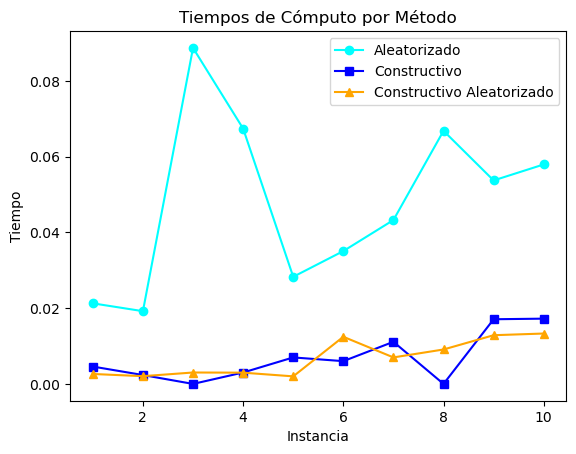

In [32]:
import matplotlib.pyplot as plt


x = range(1, len(times_random) + 1)

plt.plot(x, times_random, label="Aleatorizado", marker="o", color='cyan')
plt.plot(x, times_const, label="Constructivo", marker="s", color='blue')
plt.plot(x, times_c_random, label="Constructivo Aleatorizado", marker="^", color='orange')

plt.xlabel("Instancia")
plt.ylabel("Tiempo")
plt.title("Tiempos de Cómputo por Método")
plt.legend()

plt.show()


# Búsqueda Local

In [33]:
def accept_fo(t1, t2, t3, FO_new, FO_best):
    return (FO_new[0]<FO_best[0]) or (FO_new[0]-t1<=FO_best[0] and FO_new[1]<FO_best[1])\
            or (FO_new[0]-t1<=FO_best[0] and FO_new[1]-t2<=FO_best[1] and FO_new[2]<FO_best[2])\
            or (FO_new[0]<=FO_best[0] and FO_new[1]-t2<=FO_best[1] and FO_new[2]-t3<=FO_best[2] and FO_new[3]<FO_best[3])

In [34]:
import numpy as np
import random
import math

def get_assigned_emps(x_day):
    return np.where(x_day.sum(axis=1) > 0)[0]

def get_emp_desk(x_day, emp):
    cols = np.where(x_day[emp, :] == 1)[0]
    return int(cols[0]) if cols.size > 0 else -1

def emp_in_preference(x_day, EE, emp):
    d = get_emp_desk(x_day, emp)
    if d == -1:
        return False
    return bool(EE[emp, d] == 1)

def attempt_swap_and_eval(x_curr, y_curr, t, a, b, DZ, EE, EG, DE):

    x_try = x_curr.copy()
    row_a = x_try[t, a, :].copy()
    row_b = x_try[t, b, :].copy()
    x_try[t, a, :], x_try[t, b, :] = row_b, row_a

    if False not in const(x_try, y_curr, DZ, EE, EG, DE):
        f_new = FO(x_try, y_curr, DZ, EE, EG, DE, None)
        return True, f_new, x_try
    else:
        return False, None, None

def find_candidate_prefers_desk(x_day, EE, desk_a, exclude_set=set(), limit=10):

    assigned = get_assigned_emps(x_day)
    candidates = []
    for emp in assigned:
        if emp in exclude_set:
            continue
        if EE[emp, desk_a] == 1:
            candidates.append(emp)
            if len(candidates) >= limit:
                break
    return candidates

def find_candidate_not_pref(x_day, EE, exclude_set=set(), limit=10):
    assigned = get_assigned_emps(x_day)
    candidates = []
    for emp in assigned:
        if emp in exclude_set:
            continue
        if not emp_in_preference(x_day, EE, emp):
            candidates.append(emp)
            if len(candidates) >= limit:
                break
    return candidates

def find_occupant_of_preferred_desks(x_day, EE, emp, exclude_set=set()):
    pref_desks = np.where(EE[emp, :] == 1)[0]
    for pd in pref_desks:
        occ = np.where(x_day[:, pd] == 1)[0]
        if occ.size > 0:
            occ_emp = int(occ[0])
            if occ_emp != emp and occ_emp not in exclude_set:
                return occ_emp
    return None

def fo_lex_better(f_new, f_old):
    if f_old is None:
        return True
    return tuple(f_new) < tuple(f_old)

def group_not_day(EG, DE, y, N):
    fav_day = y@EG
    comp_group_day = np.sum(((y@EG) * DE.T), axis=0)

    groups_emp = EG@comp_group_day
    N_groups = np.argsort(groups_emp)[-N:][::-1]
    return N_groups.tolist()
    

In [35]:
def local_search(x, y, DZ, EE, EG, DE, best=False, niter=math.inf, k=5, N_groups=False, 
                 neighboor1=True, neighboor2=True, f_improvements=1):
    
    it = 0
    T, G = y.shape
    I, J = x.shape[1:]
    stop = False

    x_best = x.copy()
    y_best = y.copy()
    f_best = FO(x_best, y_best, DZ, EE, EG, DE, None)

    error = 0
    last_f_trial = None

    if N_groups:
        groups_inst = group_not_day(EG, DE, y, N_groups)
    else:
        groups_inst = range(G)

    if not neighboor1:
        groups_inst = range(1)

    while it < niter and not stop:
        improved_global = False
        for g1 in groups_inst:
            for g2 in groups_inst:
                if g1 == g2 and neighboor1:
                    continue
                if neighboor1:
                    y_candidate = insert(y_best, 1, g1, g2)
                else:
                    y_candidate = y_best
                if not R6(J, y_candidate, EG):
                    continue
                
                if neighboor2:
                    try:
                        x_candidate = group_day(x_best, y_candidate, EG, random_=False)
    
                        f_candidate = FO(x_candidate, y_candidate, DZ, EE, EG, DE, None)
                        last_f_trial = f_candidate
    
      
                        y_curr = y_candidate  
                        for t in range(T):
                            x_day = x_candidate[t]
                            assigned = get_assigned_emps(x_day)
                            if assigned.size == 0:
                                continue
    
                            L1 = find_candidate_not_pref(x_day, EE, exclude_set=set(), limit=k)
                            if len(L1) == 0:
                                continue
                            
                            if not best:
                                # FIRST-IMPROVEMENT
                                contador = 0
                                for a in L1:
                                    it += 1
                                    desk_a = get_emp_desk(x_candidate[t], a)
                                    # 1) buscar empleado que prefiera desk_a (excluyendo L1)
                                    exclude = set(L1)
                                    exclude.add(a)
                                    B = find_candidate_prefers_desk(x_candidate[t], EE, desk_a, exclude_set=exclude, limit=k)
                                    # 2) si no hay, buscar empleado que no esté en su preferencia (y no en L1)
                                    if len(B) == 0:
                                        B = find_candidate_not_pref(x_candidate[t], EE, exclude_set=exclude, limit=k)
                                    # 3) si aún no hay, buscar ocupante de alguno de los escritorios preferidos de a
                                    if len(B) == 0:
                                        occ = find_occupant_of_preferred_desks(x_candidate[t], EE, a, exclude_set=exclude)
                                        if occ is not None:
                                            B = [occ]
    
                                    # probar parejas (a,b) en orden hasta hallar mejora
                                    found = False
                                    for b in B:
                                        feasible, f_new, x_try = attempt_swap_and_eval(x_candidate, y_curr, t, a, b, DZ, EE, EG, DE)
                                        if not feasible:
                                            continue
                                        last_f_trial = f_new
                                        # requisito explícito: EA no aumenta respecto a f_candidate
                                        if f_new[0] <= f_candidate[0] and accept_fo(0, 0, 0, f_new, f_candidate):
                                            contador+=1
                                            # aceptar swap localmente (first improvement por día)
                                            x_candidate = x_try
                                            f_candidate = f_new
                                            if contador==f_improvements:
                                                found = True
                                                break
                                    if found:
                                        break
                                        
                                continue
    
                            else:
                                swaps_done = 0
                                while swaps_done < k:
                                    best_pair = None
                                    best_f = None
                                    best_x_try = None
    
                                    for a in L1:
                                        desk_a = get_emp_desk(x_candidate[t], a)
                                        exclude = set(L1)
                                        exclude.add(a)
                                        B = find_candidate_prefers_desk(x_candidate[t], EE, desk_a, exclude_set=exclude, limit=k)
                                        if len(B) == 0:
                                            B = find_candidate_not_pref(x_candidate[t], EE, exclude_set=exclude, limit=k)
                                        if len(B) == 0:
                                            occ = find_occupant_of_preferred_desks(x_candidate[t], EE, a, exclude_set=exclude)
                                            if occ is not None:
                                                B = [occ]
    
                                        for b in B:
                                            it += 1
                                            feasible, f_new, x_try = attempt_swap_and_eval(x_candidate, y_curr, t, a, b, DZ, EE, EG, DE)
                                            if not feasible:
                                                continue
                                            if f_new[0] > f_candidate[0]:
                                                continue
                                            # registrar el mejor f_new lexicográficamente
                                            if best_f is None or fo_lex_better(f_new, best_f):
                                                best_f = f_new
                                                best_pair = (a, b)
                                                best_x_try = x_try
    
                                    if best_pair is not None and fo_lex_better(best_f, f_candidate):
                                        x_candidate = best_x_try
                                        f_candidate = best_f
                                        last_f_trial = best_f
                                        swaps_done += 1
    
                                        x_day = x_candidate[t]
                                        L1 = find_candidate_not_pref(x_day, EE, exclude_set=set(), limit=k)
                                        if len(L1) == 0:
                                            break
                                    else:
                                        break
                                continue
    
                        if accept_fo(0, 0, 0, f_candidate, f_best):
                            f_best = f_candidate
                            x_best = x_candidate.copy()
                            y_best = y_candidate.copy()
                            improved_global = True
                            
                    except Exception:
                        error += 1
                        continue
                else:
                    try:
                        x_candidate = group_day(x_best, y_candidate, EG, random_=False)
                        f_candidate = FO(x_candidate, y_candidate, DZ, EE, EG, DE, None)
                        if accept_fo(0, 0, 0, f_candidate, f_best):
                            f_best = f_candidate
                            x_best = x_candidate.copy()
                            y_best = y_candidate.copy()
                            if not best:
                                break
                    except:
                        continue
                            

            # if improved_global:
            #     break

        stop = True

    return x_best, y_best, f_best, last_f_trial


## Comparaciones Best y First

### Instancia 1

In [36]:
x1, y1 = results_const[0][0], results_const[0][1]

In [37]:
with open("instances/instance1.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)


In [38]:
results_const[0][2]

(9, 454, 207, 36)

#### Best

In [39]:
start1_best = time.time()
xls1_best, yls1_best, fls1_best, new1_best = local_search(x1, y1, DZ, EE, EG, DE, best=True, k=12)
end1_best = time.time()

In [40]:
fls1_best

(5, 447, 208, 39)

In [41]:
print(f'Tiempo de best en instancia 1: {end1_best - start1_best}')

Tiempo de best en instancia 1: 0.28945350646972656


#### First

In [42]:
start1_first = time.time()
xls1_first, yls1_first, fls1_first, new1_first = local_search(x1, y1, DZ, EE, EG, DE, best=True, k=12)
end1_first = time.time()

In [43]:
fls1_first

(5, 447, 208, 39)

In [44]:
print(f'Tiempo de first en instancia 1: {end1_first - start1_first}')

Tiempo de first en instancia 1: 0.29126501083374023


#### Primer Vecindario

In [45]:
start1_n1 = time.time()
xls1_n1, yls1_n1, fls1_n1, new1_n1 = local_search(x1, y1, DZ, EE, EG, DE, best=True, k=12, neighboor2=False)
end1_n1 = time.time()

In [46]:
fls1_n1

(8, 454, 211, 38)

In [47]:
print(f'Tiempo de best en instancia 1: {end1_n1 - start1_n1}')

Tiempo de best en instancia 1: 0.018672943115234375


#### Segundo Vecindario

In [48]:
start1_n2 = time.time()
xls1_n2, yls1_n2, fls1_n2, new1_n2 = local_search(x1, y1, DZ, EE, EG, DE, best=True, k=12, neighboor1=False)
end1_n2 = time.time()

In [49]:
fls1_n2

(9, 453, 207, 36)

In [50]:
print(f'Tiempo de best en instancia 1: {end1_n2 - start1_n2}')

Tiempo de best en instancia 1: 0.004683494567871094


### Instancia 5

In [51]:
x5, y5 = results_const[4][0], results_const[4][1]

In [52]:
with open("instances/instance5.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)


In [53]:
results_const[4][2]

(24, 6596, 754, 118)

#### N-th Improvement

In [54]:
start5_first5 = time.time()
xls5_first5, yls5_first5, fls5_first5, new5_first5 = local_search(x5, y5, DZ, EE, EG, DE, best=True, k=30, N_groups=5, f_improvements=9)
end5_first5 = time.time()

In [55]:
fls5_first5

(5, 6558, 755, 144)

In [56]:
print(f'Tiempo de best en instancia 1: {end5_first5 - start5_first5}')

Tiempo de best en instancia 1: 6.357474327087402


#### Best

In [57]:
start5_best = time.time()
xls5_best, yls5_best, fls5_best, new5_best = local_search(x5, y5, DZ, EE, EG, DE, best=True, k=30, N_groups=5)
end5_best = time.time()

In [58]:
fls5_best

(5, 6558, 755, 144)

In [59]:
print(f'Tiempo de best en instancia 1: {end5_best - start5_best}')

Tiempo de best en instancia 1: 6.384726285934448


#### First

In [60]:
start5_first = time.time()
xls5_first, yls5_first, fls5_first, new5_first = local_search(x5, y5, DZ, EE, EG, DE, best=False, k=30, N_groups=5)
end5_first = time.time()

In [61]:
fls5_first

(19, 6565, 754, 148)

In [62]:
print(f'Tiempo de best en instancia 1: {end5_first - start5_first}')

Tiempo de best en instancia 1: 0.3721621036529541


#### Primer Vecindario

In [63]:
start5_n1 = time.time()
xls5_n1, yls5_n1, fls5_n1, new5_n1 = local_search(x5, y5, DZ, EE, EG, DE, best=True, k=30, neighboor2=False)
end5_n1 = time.time()

In [64]:
fls5_n1

(15, 6578, 757, 152)

In [65]:
print(f'Tiempo de best en instancia 1: {end5_n1 - start5_n1}')

Tiempo de best en instancia 1: 0.11795330047607422


#### Segundo Vecindario

In [66]:
start5_n2 = time.time()
xls5_n2, yls5_n2, fls5_n2, new5_n2 = local_search(x5, y5, DZ, EE, EG, DE, best=False, k=60, neighboor1=False)
end5_n2 = time.time()

In [67]:
fls5_n2

(24, 6596, 754, 118)

In [68]:
print(f'Tiempo de best en instancia 1: {end5_n2 - start5_n2}')

Tiempo de best en instancia 1: 0.03444504737854004


### Instancia 10

In [69]:
x10, y10 = results_const[-1][0], results_const[-1][1]

In [70]:
with open("instances/instance10.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)


In [71]:
results_const[-1][2]

(76, 14727, 1224, 197)

#### N-th Improvement

In [72]:
start10_first5 = time.time()
xls10_first5, yls10_first5, fls10_first5, new10_first5 = local_search(x10, y10, DZ, EE, EG, DE, best=False, k=30, N_groups=5, f_improvements=7)
end10_first5 = time.time()

In [73]:
fls10_first5

(52, 14706, 1223, 217)

In [74]:
print(f'Tiempo de best en instancia 1: {end10_first5 - start10_first5}')

Tiempo de best en instancia 1: 9.723187685012817


#### Best

In [75]:
start10_best = time.time()
xls10_best, yls10_best, fls10_best, new10_best = local_search(x10, y10, DZ, EE, EG, DE, best=True, k=30, N_groups=5)
end10_best = time.time()

In [76]:
fls10_best

(57, 14700, 1224, 214)

In [77]:
print(f'Tiempo de best en instancia 1: {end10_best - start10_best}')

Tiempo de best en instancia 1: 20.313568592071533


#### First

In [78]:
start10_first = time.time()
xls10_first, yls10_first, fls10_first, new10_first = local_search(x10, y10, DZ, EE, EG, DE, best=False, k=30, N_groups=5)
end10_first = time.time()

In [79]:
fls10_first

(76, 14725, 1224, 197)

In [80]:
print(f'Tiempo de best en instancia 1: {end10_first - start10_first}')

Tiempo de best en instancia 1: 0.8945109844207764


#### Primer Vecindario

In [81]:
start10_n1 = time.time()
xls10_n1, yls10_n1, fls10_n1, new10_n1 = local_search(x10, y10, DZ, EE, EG, DE, best=True, k=100, neighboor2=False)
end10_n1 = time.time()

In [82]:
fls10_n1

(76, 14727, 1224, 197)

In [83]:
print(f'Tiempo de best en instancia 1: {end10_n1 - start10_n1}')

Tiempo de best en instancia 1: 1.4916908740997314


#### Segundo Vecindario

In [84]:
start10_n2 = time.time()
xls10_n2, yls10_n2, fls10_n2, new10_n2 = local_search(x10, y10, DZ, EE, EG, DE, best=True, k=100, neighboor1=False)
end10_n2 = time.time()

In [85]:
fls10_n2

(75, 14725, 1224, 196)

In [86]:
print(f'Tiempo de best en instancia 1: {end10_n2 - start10_n2}')

Tiempo de best en instancia 1: 0.13002777099609375


# GRASP con aceptación lexicográfica y vecindad guiada

In [87]:
import numpy as np
import random
import math
from copy import deepcopy


###
# Datos
###

with open("instances/instance1.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

# ------------------------------
# Utilidades de comparación ya usadas en tu LS
# ------------------------------
def fo_lex_better(f_new, f_old):
    if f_old is None:
        return True
    return tuple(f_new) < tuple(f_old)

# ------------------------------
# Aleatorización/perturbación de Y
# ------------------------------
def perturb_y(y_base, n_moves=3, p_insert=0.6, force_axis=None):
    """
    Aplica n_moves aleatorios sobre y_base con swap/insert.
    - p_insert: probabilidad de usar insert (vs swap).
    - force_axis: None => elige; 0 => operar sobre filas; 1 => sobre columnas.
      Para Y(T,G), suele tener más sentido ax=1 (grupos/columnas).
    """
    y_new = y_base.copy()
    rows, cols = y_new.shape
    for _ in range(n_moves):
        use_insert = random.random() < p_insert
        ax = force_axis if force_axis is not None else random.randint(0, 1)
        if use_insert:
            # --- insert sobre filas o columnas ---
            i1, i2 = (random.sample(range(rows), 2) if ax == 0
                      else random.sample(range(cols), 2))
            if ax == 0:
                row = y_new[i1, :].copy()
                y_new = np.delete(y_new, i1, axis=0)
                y_new = np.insert(y_new, i2, row, axis=0)
            else:
                col = y_new[:, i1].copy()
                y_new = np.delete(y_new, i1, axis=1)
                y_new = np.insert(y_new, i2, col, axis=1)
        else:
            # --- swap sobre filas o columnas ---
            if ax == 0 and rows >= 2:
                i1, i2 = random.sample(range(rows), 2)
                a, b = y_new[i1, :].copy(), y_new[i2, :].copy()
                y_new[i1, :], y_new[i2, :] = b, a
            elif ax == 1 and cols >= 2:
                i1, i2 = random.sample(range(cols), 2)
                a, b = y_new[:, i1].copy(), y_new[:, i2].copy()
                y_new[:, i1], y_new[:, i2] = b, a
    return y_new

constructive_randomized_controlled(EG, DE, EE, DZ, min_days=2, max_days=3, seed=None)
def random_feasible_initial(x_ref, y_ref, DZ, EE, EG, DE,
                            max_tries=200,
                            moves_range=(1, 6),
                            prefer_axis=1,
                            use_constructor=None,
                            constructor_kwargs=None):
    """
    Genera una solución inicial factible (x0,y0) para iniciar cada iteración GRASP.
    Orden de intentos:
      (A) Si hay constructor voraz (use_constructor), inténtalo primero.
      (B) Aleatoriza Y mediante perturbaciones (swap/insert), valida R6 y agrupa con group_day.
    Devuelve: (x0, y0, f0) o lanza RuntimeError si no se logró.
    """
    # (A) Constructor voraz si está disponible
    if callable(use_constructor):
        try:
            kwargs = constructor_kwargs or {}
            x0_c, y0_c = use_constructor(**kwargs)
            if R6(x_ref.shape[2], y0_c, EG) and (False not in const(x0_c, y0_c, DZ, EE, EG, DE)):
                f0_c = FO(x0_c, y0_c, DZ, EE, EG, DE, None)
                return x0_c, y0_c, f0_c
        except Exception:
            pass  # cae al esquema B

    # (B) Aleatorización con perturbaciones y reintentos
    tries = 0
    while tries < max_tries:
        tries += 1
        n_moves = random.randint(*moves_range)
        y_try = perturb_y(y_ref, n_moves=n_moves, p_insert=0.7, force_axis=prefer_axis)

        # Chequeo rápido de estructura de Y (por ejemplo, validador R6)
        if not R6(x_ref.shape[2], y_try, EG):
            continue

        # Intentar construir X compatible con Y
        try:
            # Si tu group_day acepta random_ para romper empates:
            x_try = group_day(x_ref.copy(), y_try, EG, random_=True)
        except Exception:
            continue

        # Validar todas las restricciones duras
        if False not in const(x_try, y_try, DZ, EE, EG, DE):
            f0 = FO(x_try, y_try, DZ, EE, EG, DE, None)
            return x_try, y_try, f0

    raise RuntimeError("No fue posible construir solución inicial factible tras max_tries.")

# ------------------------------
# Núcleo GRASP
# ------------------------------
def grasp(
    x_start, y_start, DZ, EE, EG, DE,
    iters=50,
    ls_best=False,
    ls_k=5,
    ls_N_groups=5,
    f_improvements=5,
    patience = 10,
    seed=None,
    accept_thresholds = (0, 0, 0)):
    
    """
    GRASP genérico:
      - Genera/aleatoriza solución inicial factible por iteración.
      - Mejora con tu local_search().
      - Guarda el mejor global por lexicográfico.
    Parámetros clave:
      - ls_best: usa tu modo 'best' (True) o 'first-improvement' (False).
      - patience: nº de iteraciones sin mejora para cortar temprano.
      - use_constructor: función opcional de construcción voraz (si la tienes).
    Devuelve: (x_best, y_best, f_best, history)
    """

    start = time.time()
    
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Evaluar punto de partida (por si se quiere usar como backup)
    x_best = x_start.copy()
    y_best = y_start.copy()
    f_best = FO(x_best, y_best, DZ, EE, EG, DE, None)

    f_initial = FO(x_start, y_start, DZ, EE, EG, DE, None)
    
    history = []
    no_improve = 0

    T, G = y_start.shape
    I, J = x_start.shape[1:]

    for it in range(1, iters + 1):
        # 1) Construcción / Aleatorización para obtener (x0, y0) factibles
        try:
            
            x0, y0, df_group_day, df_emp_matrix, df_day_summary, assignments, current_assign_map = constructive_randomized_controlled(EG, DE, EE, DZ, min_days=2, max_days=3, seed=None)
        
            f0 = FO(x0, y0, DZ, EE, EG, DE)
        
        except RuntimeError:
            # Si falla la construcción, usa el mejor actual como base (variación conservadora)
            x0, y0, f0 = x_best.copy(), y_best.copy(), f_best

        # 2) Mejora local con tu rutina
        #    (acepta tu signatura: local_search(x, y, DZ, EE, EG, DE, best=False, niter=inf, k=5))
        x_loc, y_loc, f_loc, last_trial = local_search(x0, y0, DZ, EE, EG, DE, best=False, niter=math.inf, k=5, N_groups=False, 
                 neighboor1=True, neighboor2=True, f_improvements=1)

        # 3) Actualizar mejor global (lexicográfico + umbrales de accept_fo)
        t1, t2, t3 = accept_thresholds
        # Nota: accept_fo( t1, t2, t3, FO_new, FO_best )
        if accept_fo(t1, t2, t3, f_loc, f_best):
            x_best, y_best, f_best = x_loc.copy(), y_loc.copy(), tuple(f_loc)
            no_improve = 0
        else:
            no_improve += 1

        # 4) Log de iteración
        history.append({
            "iter": it,
            "f_init": tuple(f0),
            "f_loc": tuple(f_loc),
            "f_best": tuple(f_best),
            "last_trial": None if last_trial is None else tuple(last_trial),
            "no_improve": no_improve
        })

        # 5) Parada por paciencia
        if no_improve >= patience:
            break

    end = time.time()

    timer = end - start
    
    valid_assignments = 5*np.sum(EE) - f_best[1]
    employee_preferences = 5*np.sum(DE) - f_best[2]
    isolated_employees = f_best[0]
    
    return x_best, y_best, f_best, f_initial, timer, valid_assignments, employee_preferences, isolated_employees



In [88]:
with open("instances/instance1.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)

x_best, y_best, f_best, f_initial, timer, valid_assignments, employee_preferences, isolated_employees = grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_k=10,
    ls_N_groups=5,
    f_improvements=5,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
)
print("Solución inicial: ", f_initial)
print("Mejor FO:", f_best)
print("Tiempo: ", timer)

Solución inicial:  (3.0, 470.0, 214.0, 27)
Mejor FO: (2, 453, 211, 41)
Tiempo:  1.6489810943603516


In [89]:
RES = []
tejec = []
FOB = []

### Instancia 1: local_search(xp, yp, DZ, EE, EG, DE, best=True, k=10)

In [90]:
with open("instances/instance1.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=True,          # usa tu modo "best-improvement"
    ls_k=10,
    ls_N_groups=5,
    f_improvements=5,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
))
print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))


Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 1.6360502243041992


### Instancia 2: local_search(xp, yp, DZ, EE, EG, DE, best=True, k=10)

In [91]:
with open("instances/instance2.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=True,          # usa tu modo "best-improvement"
    ls_k=10,
    ls_N_groups=5,
    f_improvements=5,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
))

print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))
tejec.append(toc-tic)
FOB.append(f_best)

Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 0.4562845230102539


### Instancia 3: local_search(xp, yp, DZ, EE, EG, DE, best=False, k=20, f_improvements=4)

In [92]:
with open("instances/instance3.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=False,          # usa tu modo "best-improvement"
    ls_k=20,
    ls_N_groups=5,
    f_improvements=4,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
))

print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))
tejec.append(toc-tic)
FOB.append(f_best)

Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 2.2002737522125244


### Instancia 4: local_search(xp, yp, DZ, EE, EG, DE, best=False, k=20, f_improvements=4)

In [93]:
with open("instances/instance4.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=False,          # usa tu modo "best-improvement"
    ls_k=20,
    ls_N_groups=5,
    f_improvements=4,
    patience=12,
    seed=42,
    
    accept_thresholds=(2,5,5)  # o tolerancias relajadas si lo deseas
))

print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))
tejec.append(toc-tic)
FOB.append(f_best)

Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 10.472470760345459


(7, 2326, 496, 94)

### Instancia 5: local_search(xp, yp, DZ, EE, EG, DE, best=False, k=30, N_groups=4, f_improvements=3)

In [94]:
with open("instances/instance5.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=False,          # usa tu modo "best-improvement"
    ls_k=30,
    ls_N_groups=4,
    f_improvements=3,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
))

print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))
tejec.append(toc-tic)
FOB.append(f_best)

Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 12.592100620269775


### Instancia 6: local_search(xp, yp, DZ, EE, EG, DE, best=False, k=30, N_groups=5, f_improvements=3)

In [95]:
with open("instances/instance6.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=False,          # usa tu modo "best-improvement"
    ls_k=30,
    ls_N_groups=5,
    f_improvements=3,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
))

print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))
tejec.append(toc-tic)
FOB.append(f_best)

Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 11.606105089187622


### Instancia 7: local_search(xp, yp, DZ, EE, EG, DE, best=False, k=40, N_groups=4, f_improvements=3)

In [96]:
with open("instances/instance7.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=False,          # usa tu modo "best-improvement"
    ls_k=40,
    ls_N_groups=4,
    f_improvements=3,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
))

print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))
tejec.append(toc-tic)
FOB.append(f_best)

Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 66.85081577301025


### Instancia 8: local_search(xp, yp, DZ, EE, EG, DE, best=False, k=40, N_groups=3, f_improvements=5)

In [97]:
with open("instances/instance8.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=False,          # usa tu modo "best-improvement"
    ls_k=40,
    ls_N_groups=3,
    f_improvements=5,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
))

print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))
tejec.append(toc-tic)
FOB.append(f_best)

Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 60.540263414382935


### Instancia 9: local_search(xp, yp, DZ, EE, EG, DE, best=False, k=50, N_groups=3, f_improvements=5)

In [98]:
with open("instances/instance9.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=False,          # usa tu modo "best-improvement"
    ls_k=50,
    ls_N_groups=3,
    f_improvements=5,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
))

print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))
tejec.append(toc-tic)
FOB.append(f_best)

Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 224.92873072624207


### Instancia 10: local_search(xp, yp, DZ, EE, EG, DE, best=False, k=50, N_groups=5, f_improvements=2)

In [99]:
with open("instances/instance10.json", "r", encoding="utf-8") as f:
        data = json.load(f)
DZ, EE, EG, DE = generar_params(data)

G, I = EG.shape
T = DE.shape[1]
J = EE.shape[1]

x_init, y_init = initial_sol(
    T, I, J, G)
tic = time.time()
RES.append(grasp(
    x_start=x_init, y_start=y_init,
    DZ=DZ, EE=EE, EG=EG, DE=DE,
    iters=60,
    ls_best=False,          # usa tu modo "best-improvement"
    ls_k=50,
    ls_N_groups=5,
    f_improvements=2,
    patience=12,
    seed=42,
    
    accept_thresholds=(0,0,0)  # o tolerancias relajadas si lo deseas
))

print("Mejor FO:", f_best)
toc =time.time()
print("Tiempo transcurrido: "+str(toc-tic))
tejec.append(toc-tic)
FOB.append(f_best)

Mejor FO: (2, 453, 211, 41)
Tiempo transcurrido: 244.93194699287415


In [100]:
for i in range(10):
    filename = f'GRASP/GRASP_Resultados_Instancia {i+1}.xlsx'
    export_assignments_to_excel(RES[i], filename)



In [101]:
def results_local_search(instance, results_init, best, N_groups):
    x, y = results_init[instance-1][0], results_init[instance-1][1]
    with open(f"instances/instance{instance}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    DZ, EE, EG, DE = generar_params(data)

    f_init = results_init[instance-1][2]
    start = time.time()
    xls, yls, fls, newls = local_search(x, y, DZ, EE, EG, DE, best=best, k=x.shape[1]//2+1, N_groups=N_groups)
    end  = time.time()
    timer= end-start

    valid_assignments = 5*np.sum(EE) - fls[1]
    employee_preferences = 5*np.sum(DE) - fls[2]
    isolated_employees = fls[0]

    return xls, yls, fls, f_init, timer, valid_assignments, employee_preferences, isolated_employees

In [102]:
results_ls_best = []
N_list = [5, 5, 5, 5, 5, 5]
for i in range(10):
    results_ls_best.append(results_local_search(i+1, results_const, best=True, N_groups=5))

for i in range(10):
    filename = f'Best Improvement/Best_Improvement_Resultados_Instancia {i+1}.xlsx'
    export_assignments_to_excel(results_ls_best[i], filename)

In [103]:
results_ls_first = []
for i in range(10):
    results_ls_first.append(results_local_search(i+1, results_const, best=False, N_groups=5))

for i in range(10):
    filename = f'First Improvement/First_Improvement_Resultados_Instancia {i+1}.xlsx'
    export_assignments_to_excel(results_ls_best[i], filename)

In [104]:
for i in range(10):
    print(results_random[i][2])

(7, 454, 210, 42)
(7, 572, 257, 44)
(10.0, 2472.0, 455.0, 58)
(14, 2331, 491, 87)
(9.0, 6603.0, 758.0, 84)
(16, 6971, 777, 123)
(48, 9721, 1026, 157)
(28.0, 10486.0, 922.0, 102)
(88, 13969, 1200, 195)
(76, 14727, 1224, 197)


In [105]:
for i in range(10):
    print(results_ls_best[i][2])

(2, 447, 213, 32)
(2, 565, 257, 36)
(5, 2440, 458, 87)
(2, 2317, 489, 90)
(5, 6558, 755, 144)
(12, 6931, 774, 155)
(34, 9681, 1027, 190)
(24, 10438, 922, 180)
(70, 13947, 1202, 215)
(57, 14700, 1224, 214)


In [106]:
# ============================================
# NSGA-II multiobjetivo para el problema de escritorios
# Objetivos: minimizar (EA, PE, PD, ME)
# Representación: vector de días por grupo
# ============================================
!pip install deap -q

import json
import random
import numpy as np
from deap import base, creator, tools, algorithms
import time

# ------------------------------------------------
# Utilidad: comparación lexicográfica (por si quieres
# elegir "un" punto del frente de Pareto)
# ------------------------------------------------
def lex_better(f_new, f_best):
    """Devuelve True si f_new es mejor que f_best en orden lexicográfico."""
    if f_best is None:
        return True
    for a, b in zip(f_new, f_best):
        if a < b:
            return True
        if a > b:
            return False
    return False  # son iguales

# ------------------------------------------------
# Crear toolbox NSGA-II para una instancia específica
# ------------------------------------------------
def make_nsga_toolbox(DZ, EE, EG, DE):
    """
    Devuelve un toolbox de DEAP configurado para esta instancia:
    - Individual: vector de longitud G, cada gen en {0,...,T-1}
    - Fitness: 4 objetivos a minimizar (EA,PE,PD,ME)
    """
    G, I = EG.shape
    T = DE.shape[1]
    J = EE.shape[1]

    # Matriz grupo x día: cuántos miembros del grupo están disponibles/preferentes ese día
    GD = EG @ DE  # G x T

    # ---------- tipos de DEAP ----------
    if "FitnessMulti" not in creator.__dict__:
        creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0, -1.0, -1.0))
    if "IndGroupDays" not in creator.__dict__:
        creator.create("IndGroupDays", list, fitness=creator.FitnessMulti)

    toolbox = base.Toolbox()

    # ---------- inicialización ----------
    def sample_day_for_group(g):
        """Elige un día razonable para el grupo g (días con miembros disponibles)"""
        scores = GD[g]
        viable = np.where(scores > 0)[0]
        if len(viable) == 0:
            # ningún día "preferente", elegir un día cualquiera
            return random.randrange(T)
        return int(random.choice(viable))

    def init_individual(icls):
        """Inicializa un individuo: un día para cada grupo."""
        return icls(sample_day_for_group(g) for g in range(G))

    toolbox.register("individual", init_individual, creator.IndGroupDays)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    # ---------- decodificación ----------
    def decode_individual(ind):
        """
        Desde el vector de días por grupo construimos x,y:
        - y: T x G (binaria)
        - x: T x I x J, usando group_day sobre una matriz vacía
        """
        assignments = np.array(ind, dtype=int)
        y = build_y_from_assignments(assignments, T, G)

        # matriz x vacía
        x0 = np.zeros((T, I, J), dtype=int)

        # construir x a partir de y y EG
        x = group_day(x0, y, EG, random_=False)
        return x, y

    # ---------- evaluación multiobjetivo ----------
    def eval_ind(ind):
        try:
            x, y = decode_individual(ind)
        except Exception:
            # si hay cualquier fallo en group_day, penalización enorme
            big = 10**9
            return big, big, big, big

        feas_list = const(x, y, DZ, EE, EG, DE)
        if False in feas_list:
            # penalizar dependiendo de cuántas restricciones violas
            n_viol = sum(1 for v in feas_list if v is False)
            EA, PE, PD, ME = FO(x, y, DZ, EE, EG, DE, None)
            big = 10**5 * n_viol
            return EA + big, PE + big, PD + big, ME + big

        EA, PE, PD, ME = FO(x, y, DZ, EE, EG, DE, None)
        return EA, PE, PD, ME

    toolbox.register("evaluate", eval_ind)

    # ---------- operadores geneticos ----------
    toolbox.register("mate", tools.cxTwoPoint)

    def mut_group_days(individual, indpb=0.2):
        """Mutación: reasignar el día de algunos grupos."""
        for g in range(len(individual)):
            if random.random() < indpb:
                individual[g] = sample_day_for_group(g)
        return (individual,)

    toolbox.register("mutate", mut_group_days, indpb=1.0 / G)
    toolbox.register("select", tools.selNSGA2)

    # guardamos utilidades en el toolbox para su reutilización
    toolbox.decode_individual = decode_individual
    toolbox.problem_dims = (T, I, J, G)

    return toolbox

# ------------------------------------------------
# Ejecutar NSGA-II en una instancia
# ------------------------------------------------
def solve_instance_nsga(instance_id, pop_size=120, ngen=60, seed=42):
    """
    Corre NSGA-II en una instancia y devuelve una tupla compatible con export_assignments_to_excel:
    (x_best, y_best, f_best, f_initial, timer, valid_assignments, employee_preferences, isolated_employees)
    donde f_best = (EA, PE, PD, ME)
    """
    random.seed(seed)
    np.random.seed(seed)

    # --- cargar datos de la instancia ---
    with open(f"instances/instance{instance_id}.json", "r", encoding="utf-8") as f:
        data = json.load(f)

    DZ, EE, EG, DE = generar_params(data)
    G, I = EG.shape
    T = DE.shape[1]
    J = EE.shape[1]

    # --- solución constructiva para referencia (f_initial) ---
    x_c, y_c, assignments_c, df_group_day, df_emp_matrix, df_day_summary, diag = constructive_simple(EG, DE, EE, DZ)
    f_initial = FO(x_c, y_c, DZ, EE, EG, DE, None)

    # --- crear toolbox y población inicial ---
    toolbox = make_nsga_toolbox(DZ, EE, EG, DE)
    pop = toolbox.population(pop_size)

    # evaluar población inicial y aplicar NSGA-II
    start = time.time()
    algorithms.eaMuPlusLambda(
        pop, toolbox,
        mu=pop_size,
        lambda_=pop_size,
        cxpb=0.7,
        mutpb=0.3,
        ngen=ngen,
        verbose=False
    )
    end = time.time()
    timer = end - start

    # --- obtener frente de Pareto (primera frontera) ---
    pareto_front = tools.sortNondominated(pop, k=len(pop), first_front_only=True)[0]

    # elegir un individuo del frente (ej: mejor lexicográfico)
    best_ind = None
    best_f = None
    for ind in pareto_front:
        f = ind.fitness.values  # (EA, PE, PD, ME)
        if lex_better(f, best_f):
            best_ind = ind
            best_f = f

    # decodificar a (x,y) y re-evaluar por si quieres asegurar coherencia
    x_best, y_best = toolbox.decode_individual(best_ind)
    f_best = FO(x_best, y_best, DZ, EE, EG, DE, None)

    # métricas derivadas, siguiendo tu estilo anterior
    valid_assignments = 5 * np.sum(EE) - f_best[1]
    employee_preferences = 5 * np.sum(DE) - f_best[2]
    isolated_employees = f_best[0]

    return x_best, y_best, f_best, f_initial, timer, valid_assignments, employee_preferences, isolated_employees, pareto_front


In [107]:
results_nsga = []
paretos = []

for inst in range(1, 10+1):
    res = solve_instance_nsga(inst, pop_size=120, ngen=60, seed=42+inst)
    # res = (x_best, y_best, f_best, f_initial, timer, valid_assignments, employee_preferences, isolated_employees, pareto_front)
    results_nsga.append(res[:-1])   # sin el frente completo
    paretos.append(res[-1])        # guardar el frente de Pareto si quieres analizarlo


In [108]:
for i in range(10):
    filename = f'NSGAII/NSGAII_Resultados_Instancia_{i+1}.xlsx'
    export_assignments_to_excel(results_nsga[i], filename)


# Comparación total

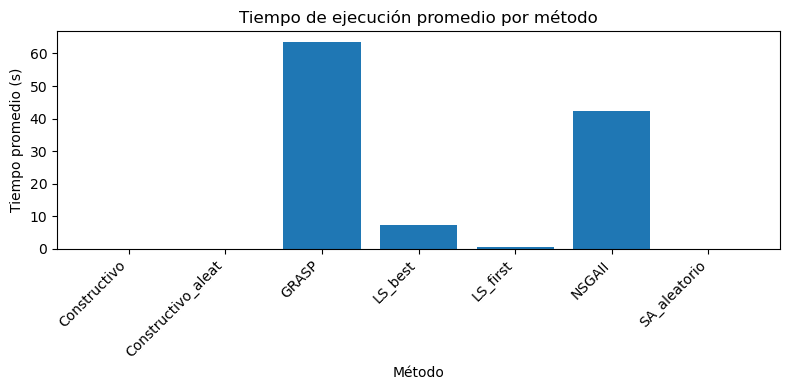

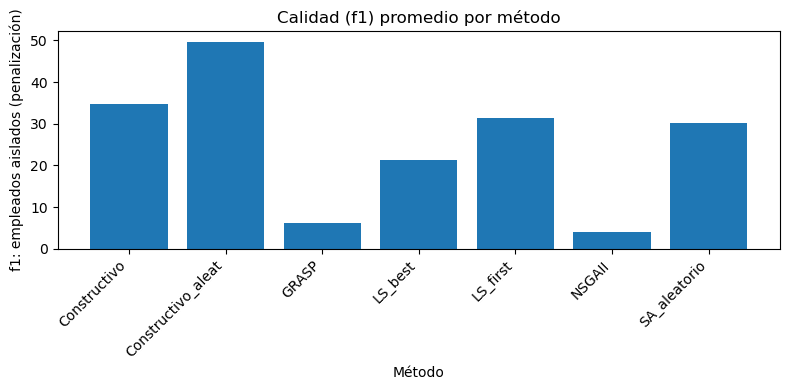

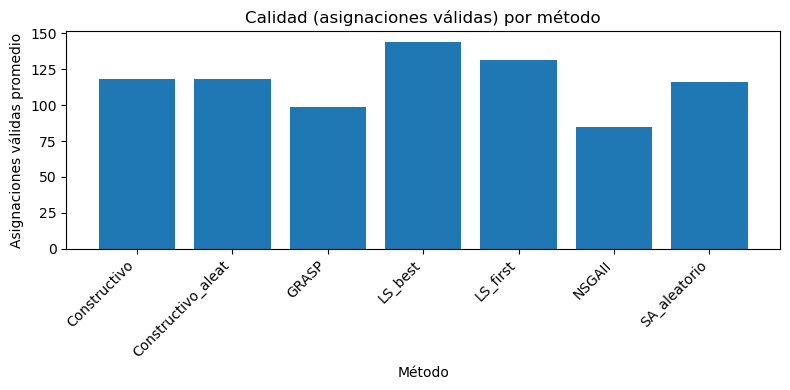

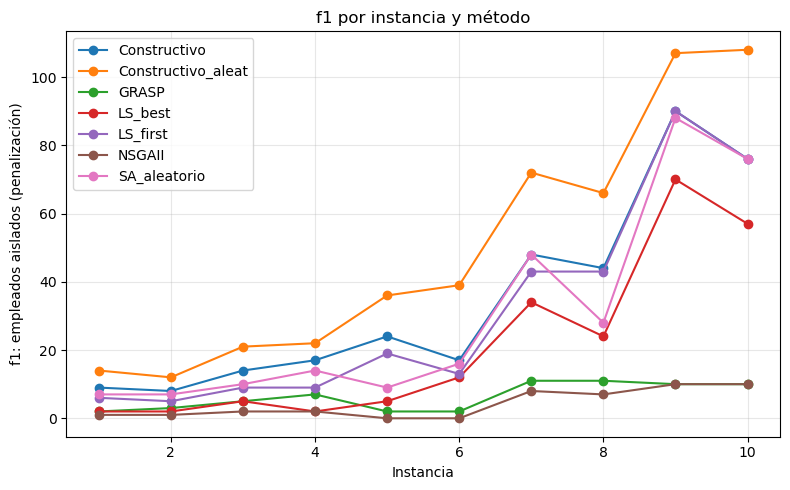

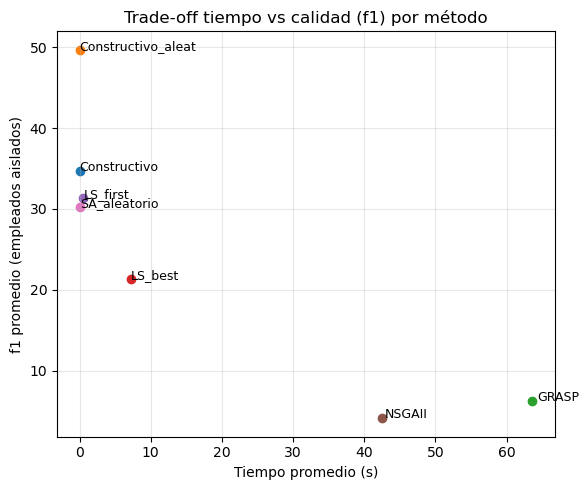

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Helper: pasar lista de resultados a DataFrame
# ---------------------------------------------------
def results_to_df(results, method_name):
    """
    results: lista de tuplas como las que devuelve evaluate / grasp / NSGA-II
    method_name: nombre del método (string)
    """
    rows = []
    for inst_idx, res in enumerate(results, start=1):
        x_best, y_best, f_best, f_initial, timer, \
        valid_assignments, employee_preferences, isolated_employees = res

        f1, f2, f3, f4 = f_best

        rows.append({
            "instance": inst_idx,
            "method": method_name,
            "time": timer,
            # objetivos originales (penalizaciones)
            "f1_isolated": f1,
            "f2_desk_pref_penalty": f2,
            "f3_day_pref_penalty": f3,
            "f4_same_desk_penalty": f4,
            # métricas derivadas (ya “positivas”)
            "valid_assignments": valid_assignments,
            "employee_preferences": employee_preferences,
            "isolated_employees_metric": isolated_employees
        })
    return pd.DataFrame(rows)

# ---------------------------------------------------
# 2. Construir un único DataFrame con todos los métodos
# ---------------------------------------------------

dfs = []

dfs.append(results_to_df(results_random,          "SA_aleatorio"))
dfs.append(results_to_df(results_const,           "Constructivo"))
dfs.append(results_to_df(results_const_random,    "Constructivo_aleat"))
dfs.append(results_to_df(results_ls_best,         "LS_best"))
dfs.append(results_to_df(results_ls_first,        "LS_first"))
dfs.append(results_to_df(RES,                     "GRASP"))
dfs.append(results_to_df(results_nsga,           "NSGAII"))

# Si ya tienes una lista con los resultados de NSGA-II de la forma
# (x_best, y_best, f_best, f_initial, timer, valid_assignments, employee_preferences, isolated_employees)
# descomenta esta línea y ajusta el nombre de la variable:


df_all = pd.concat(dfs, ignore_index=True)

# ---------------------------------------------------
# 3. Gráfica 1: tiempo promedio por método
# ---------------------------------------------------
mean_time = df_all.groupby("method")["time"].mean().reset_index()

plt.figure(figsize=(8, 4))
plt.bar(mean_time["method"], mean_time["time"])
plt.ylabel("Tiempo promedio (s)")
plt.xlabel("Método")
plt.title("Tiempo de ejecución promedio por método")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 4. Gráfica 2: f1 (empleados aislados) promedio por método
#    (recordemos que f1 es penalización, más bajo es mejor)
# ---------------------------------------------------
mean_f1 = df_all.groupby("method")["f1_isolated"].mean().reset_index()

plt.figure(figsize=(8, 4))
plt.bar(mean_f1["method"], mean_f1["f1_isolated"])
plt.ylabel("f1: empleados aislados (penalización)")
plt.xlabel("Método")
plt.title("f1: empleados aislados promedio por método")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 5. Gráfica 3: asignaciones válidas promedio por método
#    (esta métrica es “a mayor, mejor”)
# ---------------------------------------------------

mean_valid = df_all.groupby("method")["valid_assignments"].mean().reset_index()

plt.figure(figsize=(8, 4))
plt.bar(mean_valid["method"], mean_valid["valid_assignments"])
plt.ylabel("Asignaciones válidas promedio")
plt.xlabel("Método")
plt.title("Asignaciones válidas por método")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 6. Gráfica 4: comparación por instancia (ejemplo con f1)
#    Línea por método mostrando cómo se comporta en las 10 instancias
# ---------------------------------------------------
plt.figure(figsize=(8, 5))
for method, sub in df_all.groupby("method"):
    sub_sorted = sub.sort_values("instance")
    plt.plot(sub_sorted["instance"], sub_sorted["f1_isolated"],
             marker="o", label=method)

plt.xlabel("Instancia")
plt.ylabel("f1: empleados aislados (penalización)")
plt.title("f1 por instancia y método")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 7. (Opcional) Gráfica 5: trade–off tiempo vs calidad (scatter)
#    por ejemplo usando f1 como eje de calidad
# ---------------------------------------------------
mean_stats = df_all.groupby("method").agg(
    time_mean=("time", "mean"),
    f1_mean=("f1_isolated", "mean"),
).reset_index()

plt.figure(figsize=(6, 5))
for _, row in mean_stats.iterrows():
    plt.scatter(row["time_mean"], row["f1_mean"])
    plt.text(row["time_mean"] * 1.01, row["f1_mean"],
             row["method"], fontsize=9)

plt.xlabel("Tiempo promedio (s)")
plt.ylabel("f1 promedio (empleados aislados)")
plt.title("Trade-off tiempo vs calidad (f1) por método")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
